# 02 · Exploratory data analysis

Phase 3: look at the frozen 400-chunk slice before changing anything. Every number here is on the **raw** slice. Cleaning happens in `03_cleaning.ipynb`.

In [1]:
import sys
sys.path.append("../src")

import re
import pandas as pd
import matplotlib.pyplot as plt
from data import load_case_law, load_slice

BAR = "#2a78d6"   # one series per chart, so one colour
INK = "#52514e"   # axis and label text

In [2]:
case_law = load_case_law()
df = load_slice(case_law)

## 1. Overview

In [3]:
print("records:", len(df))
print("columns:", len(df.columns))
df.dtypes

records: 400
columns: 10


chunk_id          str
text              str
title             str
url               str
type              str
chunk_index     int64
total_chunks    int64
citation          str
court             str
date              str
dtype: object

### Missing values

`isna()` reports nothing missing, but that's misleading. For case law, `citation`, `court` and `date` exist and hold empty strings, so both checks are needed.

In [4]:
pd.DataFrame({
    "NaN": df.isna().sum(),
    "empty string": (df == "").sum(),
})

,NaN,empty string
chunk_id,0,0
text,0,0
title,0,0
url,0,0
type,0,0
chunk_index,0,0
total_chunks,0,0
citation,0,400
court,0,400
date,0,19


### Duplicates

In [5]:
print("duplicate chunk_id:", df["chunk_id"].duplicated().sum())
print("duplicate text:    ", df["text"].duplicated().sum())
print("distinct judgments:", df["url"].nunique())

duplicate chunk_id: 0
duplicate text:     0
distinct judgments: 272


No duplicates in the slice. For comparison, the full case-law set has 20 repeated texts:

In [6]:
case_law["text"].duplicated().sum()

np.int64(20)

### Which courts the slice comes from

In [7]:
df["court_code"] = df["url"].str.extract(r"/judgment/([a-z]+)/")[0]
df["court_code"].value_counts()

court_code
kemc      266
kehc       42
keelc      37
kekc       23
keca       16
keelrc     16
Name: count, dtype: int64

## 2. Text length

In [8]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

df[["n_chars", "n_words"]].describe()

,n_chars,n_words
count,400.000000,400.000000
mean,777.272500,132.977500
std,95.722124,18.309015
min,200.000000,30.000000
25%,800.000000,130.000000
50%,800.000000,137.000000
75%,800.000000,142.000000
max,800.000000,156.000000


In [9]:
print("exactly 800 chars:", (df["n_chars"] == 800).sum())
print("start with a lowercase letter (cut mid-sentence or mid-word):", df["text"].str.match(r"[a-z]").sum())

exactly 800 chars: 374
start with a lowercase letter (cut mid-sentence or mid-word): 291


Character length barely varies because 374 of 400 chunks are exactly 800 characters, so a histogram of it is a single bar. Word count is the more useful thing to plot:

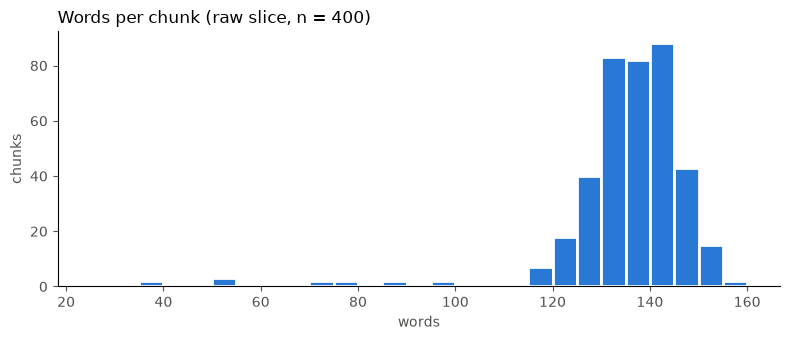

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(df["n_words"], bins=range(25, 165, 5), color=BAR, edgecolor="white", linewidth=2)

ax.set_title("Words per chunk (raw slice, n = 400)", loc="left", color="black")
ax.set_xlabel("words", color=INK)
ax.set_ylabel("chunks", color=INK)
ax.tick_params(colors=INK)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

With a fixed character count, word count mostly reflects word length, which is why it clusters tightly around 130–145. The short tail on the left comes from chunks that end before the 800-character cap.

The length distribution isn't a natural one. It reflects how the corpus author chunked the text: most chunks are cut at exactly 800 characters, wherever that falls. Most chunks start with a lowercase letter, meaning the previous chunk ended mid-sentence or mid-word. A date or case number sitting on that boundary is split between two chunks.

## 3. Legal-pattern frequency

These are rough patterns for **counting**, not the baseline extractor (that's Phase 5). The aim is to see how often each entity type appears and in what formats.

In [11]:
MONTHS = "January|February|March|April|May|June|July|August|September|October|November|December"

patterns = {
    "date: 13/7/2022":           r"\b\d{1,2}[/.-]\d{1,2}[/.-]\d{2,4}\b",
    "date: 25 March 2026":       rf"\b\d{{1,2}}(?:st|nd|rd|th)?\s+(?:{MONTHS}),?\s+\d{{4}}\b",
    "date: March 25, 2026":      rf"\b(?:{MONTHS})\s+\d{{1,2}},\s+\d{{4}}\b",
    "money: Kshs. 80,000":       r"\b(?:KES|Kshs?|KSh)\.?\s?\d[\d,]*",
    "case ref: No. 27 of 2010":  r"\b(?:No\.?\s*)?E?\d+\s+of\s+\d{4}\b",
    "case ref: [2026] KEHC 3922": r"\[\d{4}\]\s*[A-Za-z]+\s*\d+",
}

rows = []
for name, pattern in patterns.items():
    hits = df["text"].str.findall(pattern, flags=re.IGNORECASE)
    rows.append({
        "pattern": name,
        "chunks containing it": (hits.str.len() > 0).sum(),
        "total matches": hits.str.len().sum(),
        "examples": hits.explode().dropna().unique()[:3].tolist(),
    })

freq = pd.DataFrame(rows)
freq

,pattern,chunks containing it,total matches,examples
0,date: 13/7/2022,40,68,"[17/09/2007, 23/06/2022, 13/7/2022]"
1,date: 25 March 2026,45,72,"[8 November 2024, 1 March 2023, 12 July 2024]"
2,"date: March 25, 2026",13,14,"[March 24, 2026, May 5, 2025, February 19, 2025]"
3,"money: Kshs. 80,000",52,99,"[Ksh. 185,652, Ksh. 550, Kshs 4,]"
4,case ref: No. 27 of 2010,65,110,"[No. E102 of 2024, E018 of 2023, NO.E107 OF 2022]"
5,case ref: [2026] KEHC 3922,60,108,"[[2017] KESC 2, [2024] KESC 34, [1974] EA 75]"


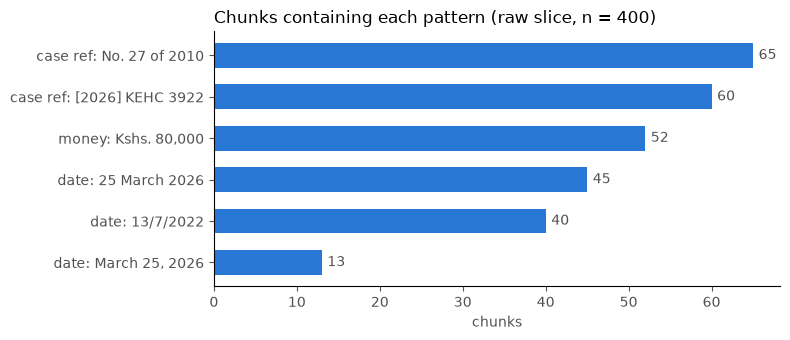

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ordered = freq.sort_values("chunks containing it")
bars = ax.barh(ordered["pattern"], ordered["chunks containing it"], color=BAR, height=0.6)
ax.bar_label(bars, padding=4, color=INK)

ax.set_title("Chunks containing each pattern (raw slice, n = 400)", loc="left", color="black")
ax.set_xlabel("chunks", color=INK)
ax.tick_params(colors=INK)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

Each entity type appears in only a minority of chunks, and each comes in more than one format. The same kind of fact is written several ways:

In [13]:
money_forms = df["text"].str.findall(r"(?:KES|Kshs?|KSh|Kenya Shillings)[^a-z]{0,25}", flags=re.IGNORECASE)
money_forms.explode().dropna().head(12).tolist()

['KES',
 'KES',
 'Ksh. 185,652/= ',
 'KES',
 'Ksh. 550/= ',
 'Kshs 4, 000 ',
 'Kshs. 7,000, ',
 'Kshs.7,409 ',
 'Kshs.7,779.45 ',
 'Ksh.8,500 ',
 'Kshs.10,000. ',
 'Kshs.54,420.50 ']

Money shows up as `Ksh.`, `Kshs.`, `Kshs` with no space, `/=` endings, `.00` decimals and spelled-out words (*"Kenya Shillings One Million"*). One case even has a stray space inside the number (`Kshs 4, 000`).

The bare `KES` matches at the top of that list aren't money at all. They come from the Supreme Court code inside citations such as `[2017] KESC 2`. It's an early example of the false positives a regex-only approach produces.

## 4. Data-quality issues found

In [14]:
page_only_urls = case_law.groupby("url")["text"].apply(lambda t: t.str.contains("Loading PDF").any())
df["page_only"] = df["url"].map(page_only_urls)

print("judgments in full case_law that are page-header only:", page_only_urls.sum(), "of", len(page_only_urls))
print("chunks in slice from those judgments:", df["page_only"].sum())

judgments in full case_law that are page-header only: 348 of 990
chunks in slice from those judgments: 19


In [15]:
df.loc[df["page_only"], "text"].iloc[0]

'E218 of 2024 Judges SG Kairu, KI Laibuta, GW Ngenye-Macharia Judgment date 25 March 2026 Language English Type Judgment Original source file Download DOCX (32.8 KB) Case action Ruling Skip to document content Loading PDF... This document is 32.8 KB. Do you want to load it? Load document ▲ To the top'

**The biggest issue.** 348 of the 990 judgments (35%) contain only the Kenya Law web-page header: title, court, judges, "Download DOCX", "Loading PDF… Do you want to load it?". The judgment itself was a PDF that was never scraped. These chunks read more like a structured metadata form than judgment text, and they are full of dates and case numbers. Left in, they would make the baseline look better than it is on real judgment prose.

These are also exactly the rows with an empty `date` field:

In [16]:
pd.crosstab(case_law["date"] == "", case_law["url"].map(page_only_urls),
            rownames=["date is empty"], colnames=["page-header only"])

page-header only,False,True
date is empty,,
False,16626,0
True,0,727


In [17]:
issues = pd.DataFrame({
    "issue": [
        "chunk from a page-header-only judgment",
        "leading or trailing whitespace",
        "non-breaking space (\\xa0) in title",
        "curly quotes / ellipsis characters",
        "spaced ordinal, e.g. '19 TH DAY'",
    ],
    "chunks affected": [
        df["page_only"].sum(),
        (df["text"] != df["text"].str.strip()).sum(),
        df["title"].str.contains("\xa0").sum(),
        df["text"].str.contains("[\u2018\u2019\u201c\u201d\u2026]").sum(),
        df["text"].str.contains(r"\d+ (?:TH|ST|ND|RD)\b", case=False).sum(),
    ],
})
issues

,issue,chunks affected
0,chunk from a page-header-only judgment,19
1,leading or trailing whitespace,94
2,non-breaking space (\xa0) in title,400
3,curly quotes / ellipsis characters,219
4,"spaced ordinal, e.g. '19 TH DAY'",114


## Summary

- **400 chunks from 272 judgments**, with no duplicate IDs or texts in the slice.
- **`citation` and `court` are always empty**, and `date` is empty on 19 chunks. `isna()` doesn't show this.
- **Length is set by the chunking, not the writing**: most chunks are exactly 800 characters and most start mid-sentence.
- **Dates, money and case references each appear in a minority of chunks**, and each in several formats.
- **19 chunks come from page-header-only judgments** with no judgment text. Removing them is the main cleaning step (next notebook).